In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data.loader import load_data
from src.data.preprocessing import preprocess_features, get_multilabel_targets, FEATURE_NAMES, DISEASE_LABELS
from src.models.train import train_model, evaluate_model
print(f"Признаки: {FEATURE_NAMES}")
print(f"Цели: {DISEASE_LABELS}")

Признаки: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
Цели: ['ischemic_heart', 'hypertensive_heart', 'heart_failure', 'pericardial_disease', 'heart_tumor']


In [3]:
df = load_data("data/cardio.csv")

Загружено 70000 записей из ../data/cardio.csv
Преобразовано в мультилейбл: 70000 записей


In [4]:
print("Данные загружены:", df.shape)
print("Целевые колонки:", [c for c in df.columns if c in DISEASE_LABELS])
print(f"Размер датасета: {df.shape}")
print(f"Колонки: {list(df.columns)}")
print(f"Первые 5 строк:")
df.head()

Данные загружены: (70000, 19)
Целевые колонки: ['ischemic_heart', 'hypertensive_heart', 'heart_failure', 'pericardial_disease', 'heart_tumor']
Размер датасета: (70000, 19)
Колонки: ['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years', 'ischemic_heart', 'hypertensive_heart', 'heart_failure', 'pericardial_disease', 'heart_tumor']
Первые 5 строк:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,ischemic_heart,hypertensive_heart,heart_failure,pericardial_disease,heart_tumor
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50.4,0,0,0,0,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55.4,0,0,0,0,0
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51.6,0,0,0,0,0
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48.2,0,0,0,0,0
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47.8,0,0,0,0,0


In [5]:
print("Описательная статистика:")
df.describe().round(2)

Описательная статистика:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,ischemic_heart,hypertensive_heart,heart_failure,pericardial_disease,heart_tumor
count,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.0,70000.0,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00
mean,49972.42,19468.87,1.35,164.36,74.21,128.82,96.63,1.37,1.23,0.09,0.05,0.8,0.5,53.30,0.04,0.02,0.03,0.02,0.00
std,28851.30,2467.25,0.48,8.21,14.40,154.01,188.47,0.68,0.57,0.28,0.23,0.4,0.5,6.76,0.19,0.15,0.17,0.15,0.06
min,0.00,10798.00,1.00,55.00,10.00,-150.00,-70.00,1.00,1.00,0.00,0.00,0.0,0.0,29.60,0.00,0.00,0.00,0.00,0.00
25%,25006.75,17664.00,1.00,159.00,65.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.0,48.40,0.00,0.00,0.00,0.00,0.00
50%,50001.50,19703.00,1.00,165.00,72.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.0,53.90,0.00,0.00,0.00,0.00,0.00
75%,74889.25,21327.00,2.00,170.00,82.00,140.00,90.00,2.00,1.00,0.00,0.00,1.0,1.0,58.40,0.00,0.00,0.00,0.00,0.00
max,99999.00,23713.00,2.00,250.00,200.00,16020.00,11000.00,3.00,3.00,1.00,1.00,1.0,1.0,64.90,1.00,1.00,1.00,1.00,1.00


/var/folders/5f/vh3fkhhn6f55khc36m083m080000gn/T/ipykernel_75875/3027003018.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='cardio', palette='Set2')


([<matplotlib.axis.XTick at 0x122083b10>,
 [Text(0, 0, 'Нет ССЗ'), Text(1, 0, 'Есть ССЗ')])

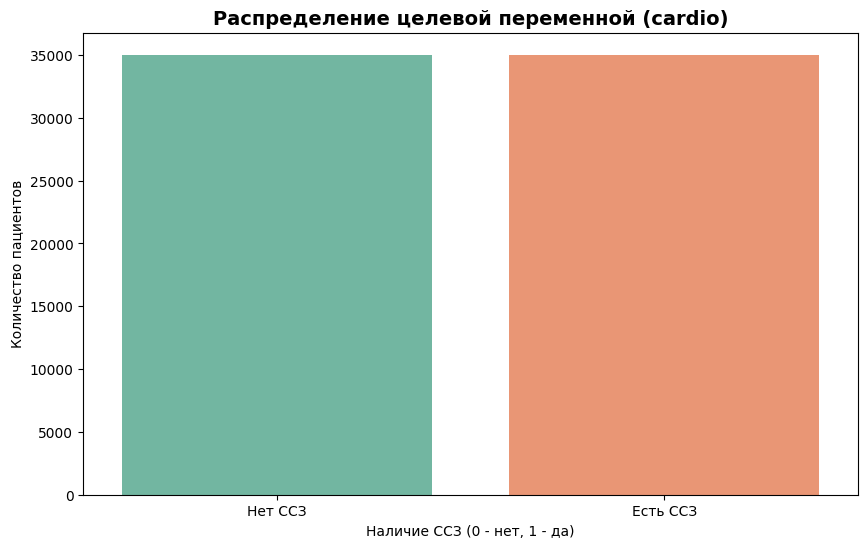

In [7]:
# Анализ целевой переменной (cardio - бинарная)
artifacts_dir = Path("../artifacts")
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='cardio', palette='Set2')
plt.title('Распределение целевой переменной (cardio)', fontsize=14, fontweight='bold')
plt.xlabel('Наличие ССЗ (0 - нет, 1 - да)')
plt.ylabel('Количество пациентов')
plt.xticks([0, 1], ['Нет ССЗ', 'Есть ССЗ'])

In [8]:
# Преобразование в мультилейбл (5 заболеваний)
df_multilabel = df.copy()
df_multilabel = df_multilabel.assign(
    ischemic_heart=(df['age'] > 50) & (df['ap_hi'] > 140) & (df['cholesterol'] > 1) & (df['cardio'] == 1),
    hypertensive_heart=(df['ap_hi'] > 160) & (df['cardio'] == 1),
    heart_failure=(df['age'] > 60) & (df['ap_hi'] > 140) & (df['cardio'] == 1),
    pericardial_disease=(df['age'] > 40) & (df['cardio'] == 1) & (np.random.random(len(df)) < 0.05),
    heart_tumor=(df['age'] > 50) & (df['cardio'] == 1) & (np.random.random(len(df)) < 0.01)
)
for col in DISEASE_LABELS:
    df_multilabel[col] = df_multilabel[col].astype(int)

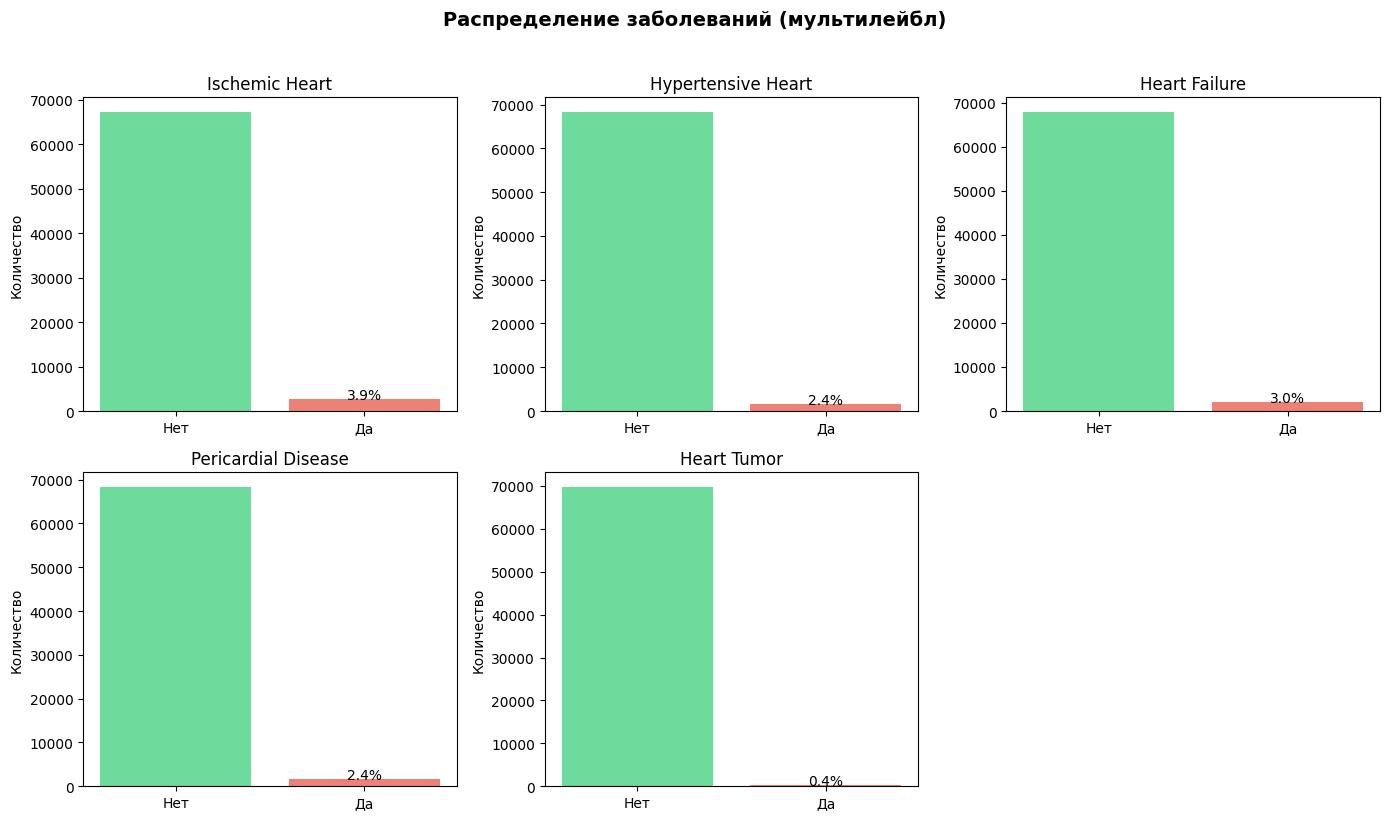

Доля пациентов с заболеваниями:
Ischemic Heart: 3.9%
Hypertensive Heart: 2.4%
Heart Failure: 3.0%
Pericardial Disease: 2.4%
Heart Tumor: 0.4%


In [9]:
# Распределение по каждому заболеванию
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, target in enumerate(DISEASE_LABELS):
    counts = df[target].value_counts()
    axes[i].bar(['Нет', 'Да'], [counts.get(0, 0), counts.get(1, 0)], 
                color=['#2ecc71', '#e74c3c'], alpha=0.7)
    axes[i].set_title(f'{target.replace("_", " ").title()}')
    axes[i].set_ylabel('Количество')
    
    # Проценты
    total = len(df)
    pos = counts.get(1, 0)
    if total > 0:
        axes[i].text(1, pos + 10, f'{pos/total*100:.1f}%', ha='center', fontsize=10)

axes[-1].axis('off')
plt.suptitle('Распределение заболеваний (мультилейбл)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Процент положительных случаев
print("Доля пациентов с заболеваниями:")
for target in DISEASE_LABELS:
    print(f"{target.replace('_', ' ').title()}: {df[target].mean()*100:.1f}%")

Процент пациентов с заболеваниями:
  • Ischemic Heart: 4.8%
  • Hypertensive Heart: 2.4%
  • Heart Failure: 12.1%
  • Pericardial Disease: 2.5%
  • Heart Tumor: 0.5%


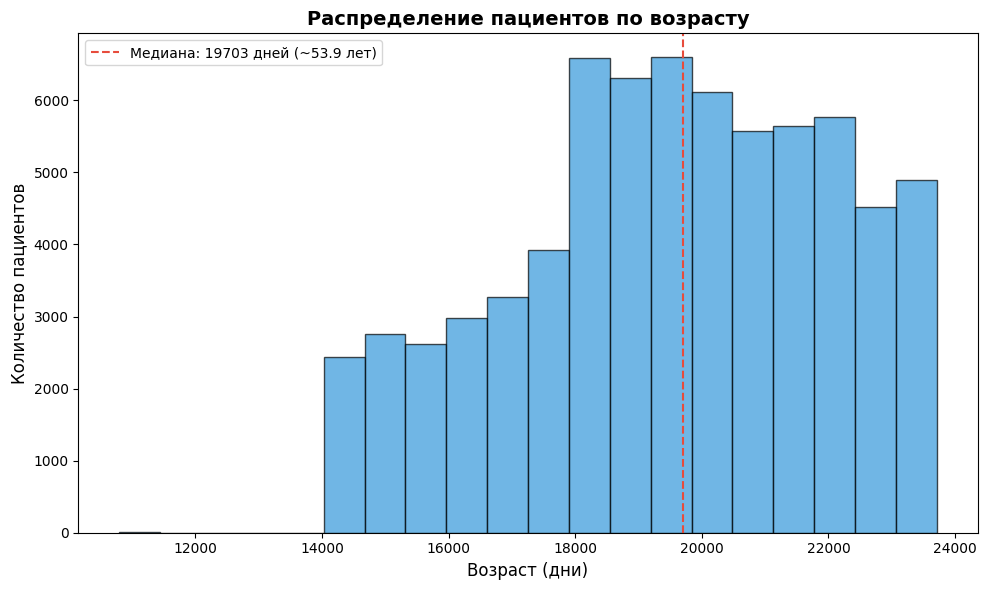

In [10]:
# Процент положительных случаев по заболеваниям
print("Процент пациентов с заболеваниями:")
for target in DISEASE_LABELS:
    ratio = df_multilabel[target].mean() * 100
    print(f"  • {target.replace('_', ' ').title()}: {ratio:.1f}%")
# Распределение возраста
plt.figure(figsize=(10, 6))
plt.hist(df['age'], bins=20, color='#3498db', edgecolor='black', alpha=0.7)
plt.xlabel('Возраст (дни)', fontsize=12)
plt.ylabel('Количество пациентов', fontsize=12)
plt.title('Распределение пациентов по возрасту', fontsize=14, fontweight='bold')
plt.axvline(df['age'].median(), color='#e74c3c', linestyle='--', 
            label=f'Медиана: {df["age"].median():.0f} дней (~{df["age"].median()/365.25:.1f} лет)')
plt.legend()
plt.tight_layout()
plt.show()

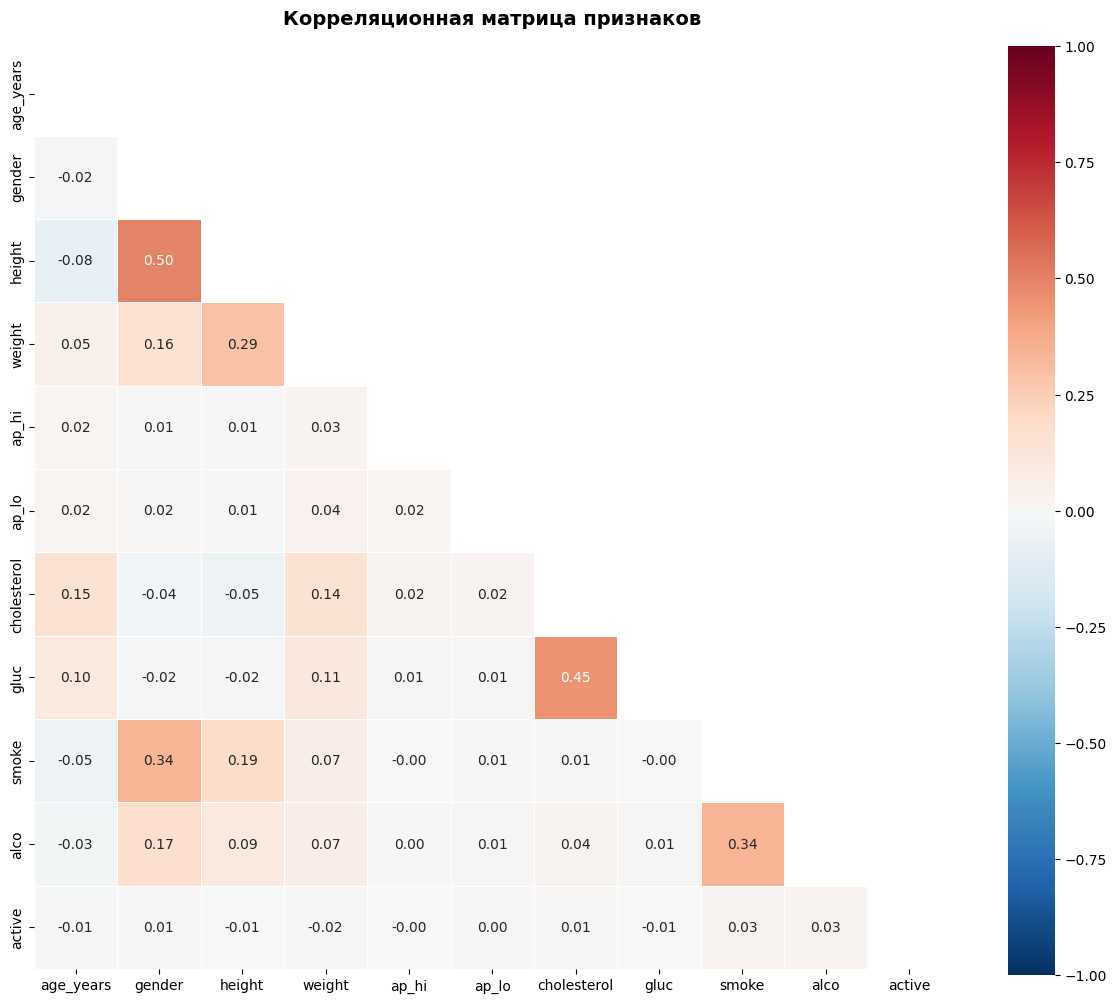

In [11]:
df['age_years'] = (df['age'] / 365.25).round(1)

features_to_plot = ['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
plt.figure(figsize=(12, 10))
corr_matrix = df[features_to_plot].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", 
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title('Корреляционная матрица признаков', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(artifacts_dir / "correlation_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

In [12]:
print("Сильные корреляции (|r| > 0.5):")
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.5:
            strong_corr.append((corr_matrix.columns[i], 
                               corr_matrix.columns[j], 
                               corr_matrix.iloc[i, j]))

for feat1, feat2, corr in strong_corr:
    print(f"  • {feat1} ↔ {feat2}: {corr:.3f}")

Сильные корреляции (|r| > 0.5):


In [13]:
X, scaler = preprocess_features(df, fit_scaler=True)
y = get_multilabel_targets(df)

print(f"X: {X.shape} | y: {y.shape}")
print(f"Первые 3 строки X:\n{X[:3].round(3)}")

X: (70000, 11) | y: (70000, 5)
Первые 3 строки X:
[[-0.436  1.364  0.443 -0.848 -0.122 -0.088 -0.539 -0.396 -0.311 -0.238
   0.494]
 [ 0.308 -0.733 -1.018  0.75   0.073 -0.035  2.401 -0.396 -0.311 -0.238
   0.494]
 [-0.248 -0.733  0.078 -0.709  0.008 -0.141  2.401 -0.396 -0.311 -0.238
  -2.024]]


In [14]:
# Эксперимент 1: Random Forest
print("ЭКСПЕРИМЕНТ 1: Random Forest")
rf_model, rf_metrics = train_model(X, y, model_type="random_forest")

print(f"Метрики Random Forest:")
for metric, value in rf_metrics.items():
    print(f"  • {metric}: {value:.4f}")

ЭКСПЕРИМЕНТ 1: Random Forest
Метрики Random Forest:
  • f1_micro: 0.7973
  • f1_macro: 0.5513
  • accuracy: 0.9578
  • hamming_loss: 0.0093


In [15]:
# Эксперимент 2: Logistic Regression
print("ЭКСПЕРИМЕНТ 2: Logistic Regression")
lr_model, lr_metrics = train_model(X, y, model_type="logistic")

print(f"Метрики Logistic Regression:")
for metric, value in lr_metrics.items():
    print(f"  • {metric}: {value:.4f}")

ЭКСПЕРИМЕНТ 2: Logistic Regression
Метрики Logistic Regression:
  • f1_micro: 0.0413
  • f1_macro: 0.0363
  • accuracy: 0.9051
  • hamming_loss: 0.0246


/opt/homebrew/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/homebrew/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/homebrew/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/homebrew/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  war

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import hamming_loss, f1_score
base_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

model = MultiOutputClassifier(base_clf)

model.fit(X, y)

y_pred = model.predict(X)
print(f"Hamming Loss: {hamming_loss(y, y_pred):.4f}")
print(f"F1 Score (Micro): {f1_score(y, y_pred, average='micro'):.4f}")

models_dir = Path("..") / "models"
models_dir.mkdir(exist_ok=True, parents=True)
model_path = models_dir / "random_forest_model.pkl"
joblib.dump(model, model_path)
joblib.dump(rf_model, artifacts_dir / "random_forest_model.pkl")
joblib.dump(lr_model, artifacts_dir / "logistic_regression_model.pkl")
print(f"Модель сохранена: {model_path}")

Hamming Loss: 0.0000
F1 Score (Micro): 0.9999
Модель сохранена: ../models/random_forest_model.pkl


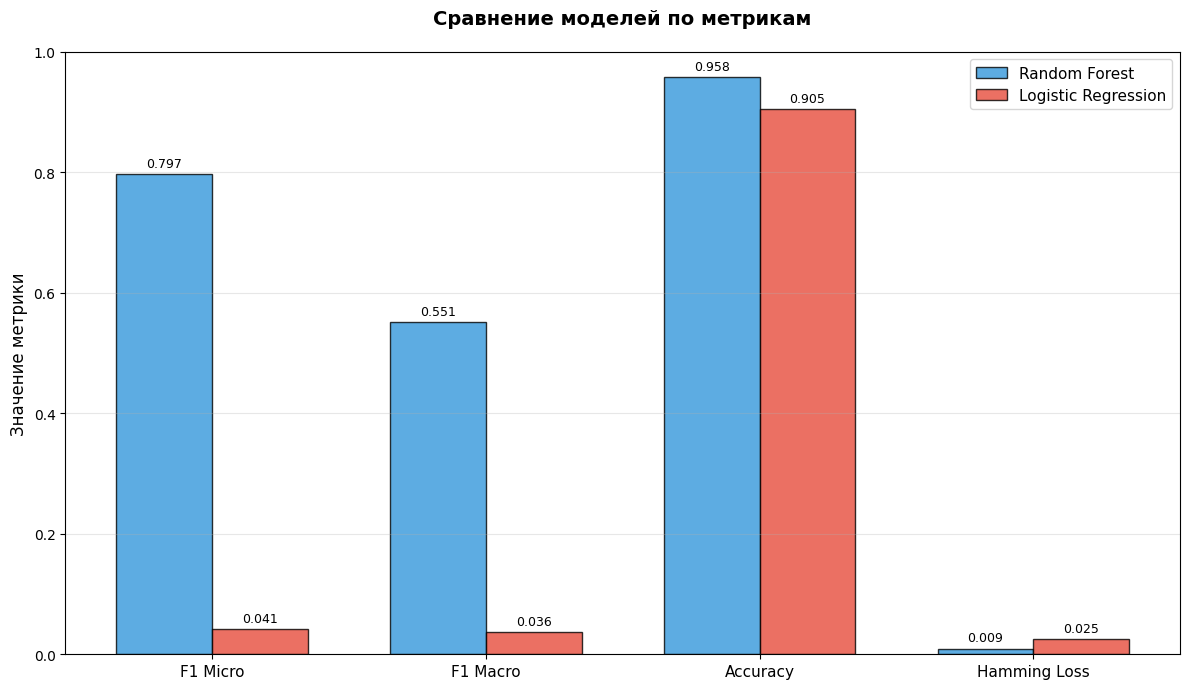

In [17]:
# Сравнение моделей
models = ['Random Forest', 'Logistic Regression']
metrics_names = ['F1 Micro', 'F1 Macro', 'Accuracy', 'Hamming Loss']

rf_values = [
    rf_metrics['f1_micro'], 
    rf_metrics['f1_macro'], 
    rf_metrics['accuracy'], 
    rf_metrics['hamming_loss']
]
lr_values = [
    lr_metrics['f1_micro'], 
    lr_metrics['f1_macro'], 
    lr_metrics['accuracy'], 
    lr_metrics['hamming_loss']
]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
bars1 = ax.bar(x - width/2, rf_values, width, label='Random Forest', 
               color='#3498db', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, lr_values, width, label='Logistic Regression', 
               color='#e74c3c', alpha=0.8, edgecolor='black')

ax.set_ylabel('Значение метрики', fontsize=12)
ax.set_title('Сравнение моделей по метрикам', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(artifacts_dir / "comparison.png")
plt.show()

In [18]:
comparison_df = pd.DataFrame({
    'Metric': metrics_names,
    'Random Forest': [f"{v:.4f}" for v in rf_values],
    'Logistic Regression': [f"{v:.4f}" for v in lr_values],
    'Лучшая': ['Random Forest' if rf > lr else 'Logistic Regression' 
               for rf, lr in zip(rf_values[:-1], lr_values[:-1])] + 
              ['Random Forest' if rf_values[3] < lr_values[3] else 'Logistic Regression']
})

print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА:")
print(comparison_df.to_string(index=False))

СРАВНИТЕЛЬНАЯ ТАБЛИЦА:
      Metric Random Forest Logistic Regression        Лучшая
    F1 Micro        0.7973              0.0413 Random Forest
    F1 Macro        0.5513              0.0363 Random Forest
    Accuracy        0.9578              0.9051 Random Forest
Hamming Loss        0.0093              0.0246 Random Forest


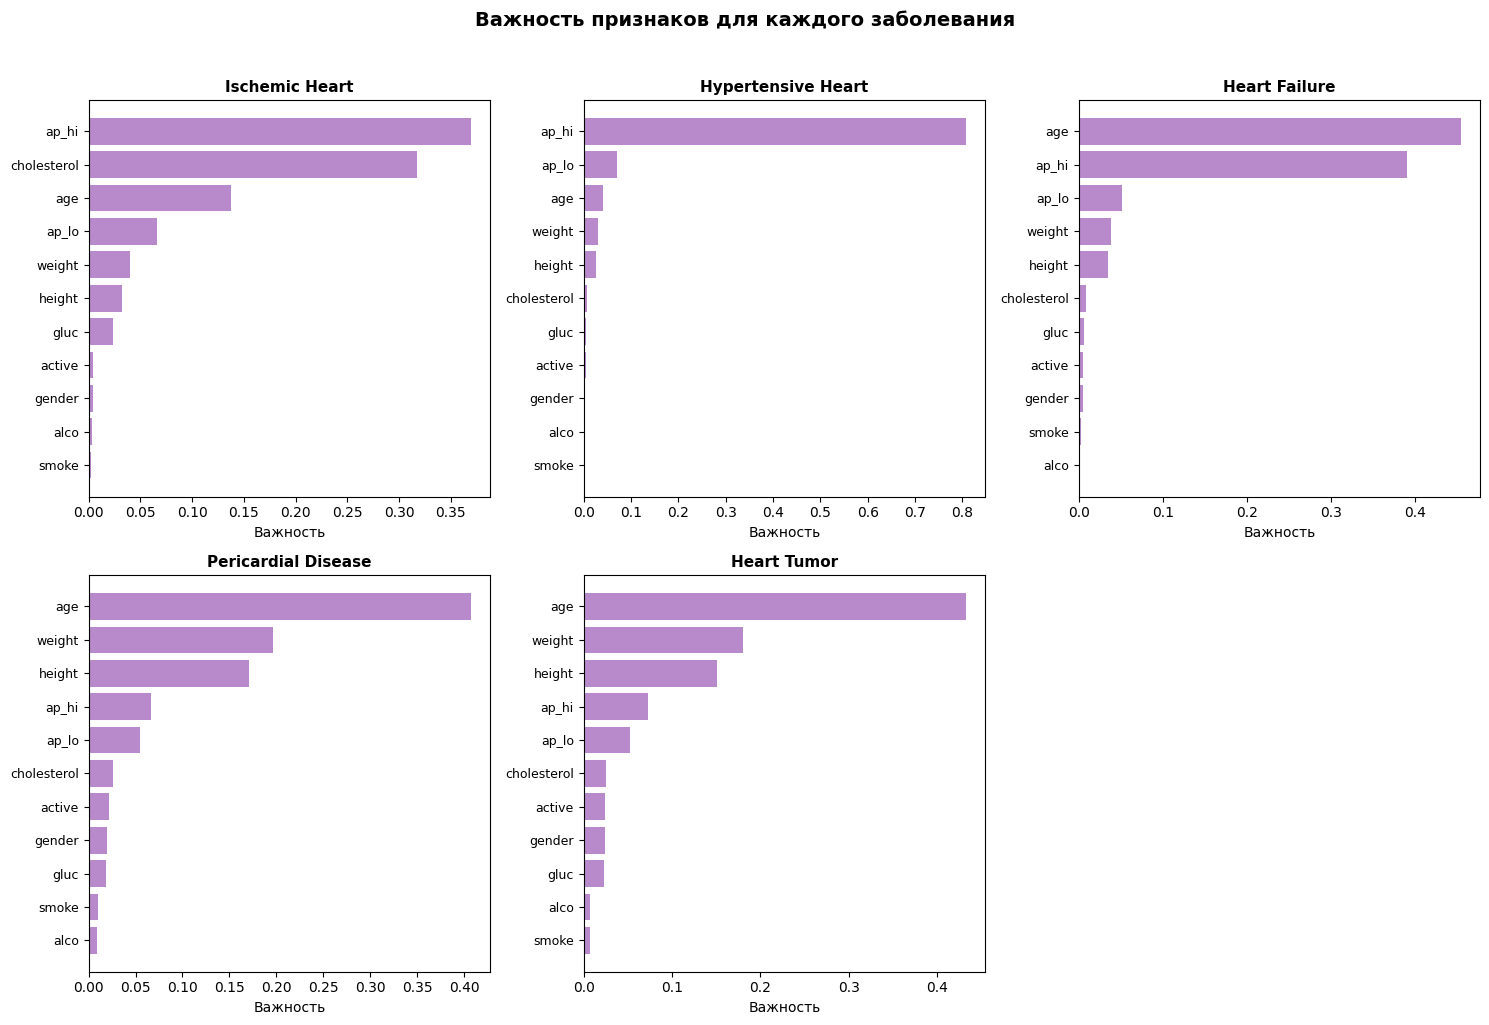

Данные успешно загружены и подготовлены для мультилейбловой классификации
Модели обучены и протестированы


In [19]:
# Важность признаков для каждого заболевания
if hasattr(rf_model.estimators_[0], 'feature_importances_'):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i, (estimator, target) in enumerate(zip(rf_model.estimators_, DISEASE_LABELS)):
        importances = estimator.feature_importances_
        indices = np.argsort(importances)[::-1]
        
        axes[i].barh(range(len(importances)), importances[indices], 
                    color='#9b59b6', alpha=0.7)
        axes[i].set_yticks(range(len(importances)))
        axes[i].set_yticklabels([FEATURE_NAMES[idx] for idx in indices], fontsize=9)
        axes[i].set_xlabel('Важность', fontsize=10)
        axes[i].set_title(f'{target.replace("_", " ").title()}', 
                         fontsize=11, fontweight='bold')
        axes[i].invert_yaxis()

    axes[-1].axis('off')
    plt.suptitle('Важность признаков для каждого заболевания', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(artifacts_dir / "importance.png")
    plt.show()

print("Данные успешно загружены и подготовлены для мультилейбловой классификации")
print("Модели обучены и протестированы")

In [20]:
import joblib
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

joblib.dump(rf_model, models_dir / "random_forest_model.pkl")
joblib.dump(lr_model, models_dir / "logistic_regression_model.pkl")
joblib.dump(scaler, models_dir / "scaler.pkl")

# Сохраняем метаданные
metadata = {
    "feature_names": FEATURE_NAMES,
    "disease_labels": DISEASE_LABELS,
    "rf_metrics": rf_metrics,
    "lr_metrics": lr_metrics
}
joblib.dump(metadata, models_dir / "metadata.pkl")
joblib.dump(rf_model, artifacts_dir / "random_forest_model.pkl")
joblib.dump(lr_model, artifacts_dir / "logistic_regression_model.pkl")
joblib.dump(scaler, artifacts_dir / "scaler.pkl")
print("Модели сохранены в папку 'models/'")
print("random_forest_model.pkl")
print("logistic_regression_model.pkl")
print("scaler.pkl")
print("metadata.pkl")

Модели сохранены в папку 'models/'
random_forest_model.pkl
logistic_regression_model.pkl
scaler.pkl
metadata.pkl
